In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import InputFiles as I, Calculators as C, Datasets as D, Parsers as P, Utilities as U
from mppi.Calculators import Tools
from mppi.Models import GaussianPulse as G
from mppi.Datasets import PostProcessing as PP
import matplotlib.pyplot as plt
import numpy as np
import os, shutil
from scipy.signal import argrelextrema

## Analysis of the Transient absorption vs Non-linear $\chi$

We study the compared description of the transient absorption based on the pump and probe induced polarization with the one
based on the non-linear chi computed on the basis of the polarization produced by a single pulse.

We use the SAVE folder and collisions matrix elements computed by D.Sangalli here

_/work/sangalli/simulations/LiF/yambo/e80_kx6_pbe_sr/kx8_nb100/NoTr_E100_.

## Test of the extraction of the non-linear $\chi$

In order to compute these quantities we perform a RT simulation using yambo_nl and then we extract the chi's using a postprocessing. Both an analysis based on the yambopy package and an original analysis developed here will be performed 

### RT simulation with yambo_nl in the IP approximation

As a first step we peform the RT simulation in the IP approximation.

WE choose the parameters from the folder

/work/sangalli/simulations/LiF/yambo/e80_kx6_pbe_sr/kx8_nb100/NoTr_E100/sh6.0+str0.05_probes/tdberry

and in particular from td-ip-ber_3.0as_inv_3-12b_delta1.0fs_deph0.1fs_p_NL, reducing the bands to 3-6

SOFTSIN:  E(t)= (c*t^2 + b*t^3 + a*t^4 )* sin(t)  and 0 for t<=0

In [3]:
# RunRules for ismhpc
# The product of ntasks_per_node*cpus_per_task is equal to 32. 
# Many mpi are needed for better performances
nodes = 1
ntasks_per_node = 32 #16
cpus_per_task = 1 #2
omp_num_threads = 1 #2
module = '/home/dalessandro/module_script/yambo_module'

ntasks = nodes*ntasks_per_node

rr = C.RunRules(scheduler='slurm',partition='all12h', #'all12h',
                memory='125000',
                nodes=nodes,ntasks_per_node=ntasks_per_node,
                cpus_per_task=cpus_per_task,
                omp_num_threads=omp_num_threads,pre_processing=module)
code = C.YamboCalculator(rr,executable='yambo_nl',activate_BeeOND=True)
#code.global_options()

Initialize a Yambo calculator with scheduler slurm


In [4]:
run_dir = 'kx8_nb100_NoTr_E100/'

In [5]:
NLBands = [3,6]
GfnQP_E = [6.,1.05,1.05]
NLEnRange = [2.0,3.0] # energy range of the probe
NLEnSteps = 4 # number of steps for the loop on frequencies

Field1_Freq, Field2_Freq = -0.1, 1.55 # eV Energy of the pump pulse
Field1_Int, Field2_Int = 1000, 1000
Field1_Dir, Field2_Dir = [1.,0.,0.], [1.,0.,0.]
Field1_kind, Field2_kind = ' SOFTSIN', ' SOFTSIN'
Field1_Tstart, Field2_Tstart = 0.1, 0.1 # fs
NLDamping = 0.2 # eV
NLtime, NLstep = 150, 0.05  # fs
IOtime = [1.,5.,0.005] #fs

inp = I.YamboInput(args='yambo_nl -u n',folder=run_dir)
inp.set_array_variables(NLBands=NLBands,GfnQP_E=GfnQP_E,NLEnSteps=NLEnSteps)
inp.set_array_variables(units='eV',NLEnRange=NLEnRange,Field1_Freq=Field1_Freq,Field2_Freq=Field2_Freq,NLDamping=NLDamping)
inp.set_array_variables(units='kWLm2',Field1_Int=Field1_Int,Field2_Int=Field2_Int)
inp.set_array_variables(Field1_Dir=Field1_Dir,Field2_Dir=Field2_Dir)
inp.set_array_variables(units='fs',Field1_Tstart=Field1_Tstart,Field2_Tstart=Field2_Tstart,NLtime=NLtime,NLstep=NLstep)
inp.set_scalar_variables(Field1_kind=Field1_kind,Field2_kind=Field2_kind)
inp.set_array_variables(units='fs',IOtime=IOtime)
inp.set_scalar_variables(NL_ROLEs="w.k",NL_CPU='4.8')
#inp

In [6]:
study = D.Dataset(num_tasks=1,run_dir=run_dir,verbose=True)
study.set_postprocessing_function(PP.yambo_parse_data)
idd = 'test2'
study.append_run(id=idd,input=inp,runner=code,jobname=[idd]) #,reformat=False

Initialize a Dataset with 1 parallel tasks


In [7]:
# study.runs[0]

In [8]:
results = study.run()

Run the selection [0] with the parallel task_groups [[0]] 

Run the task [0] 
Skip the run of test2


--------------------------------------------------------------------------

  Local host:   frontend
  Local device: mlx5_0
--------------------------------------------------------------------------


Task [0] ended 
 


In [9]:
freq = 'F1'
time = results[0].data['NL_Etot_%s'%freq]['col1']
Ex = results[0].data['NL_Etot_%s'%freq]['col2']
Px = results[0].data['NL_pol_%s'%freq]['col2']

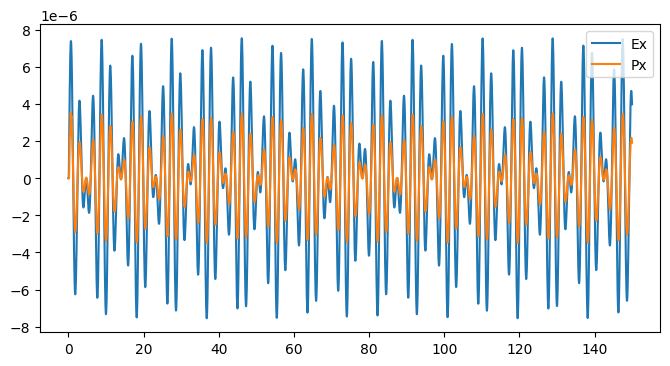

In [10]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(time,Ex,label='Ex')
ax1.plot(time,20*Px,label='Px')
ax1.legend()

In [11]:
from mppi.Utilities.FourierTransform import eval_FT

In [12]:
ft_data = eval_FT(time,Px,time_units = 'fs', verbose=True)
energy = ft_data['energy']
Pw_real, Pw_im = ft_data['ft_real'], ft_data['ft_im']

ft_data = eval_FT(time,Ex,time_units = 'fs', verbose=False)
Ew_real, Ew_im = ft_data['ft_real'], ft_data['ft_im']

Time values expressed in fs. Energy array is provided in eV.
Maximum energy value = 41.329105842026664
Energy sampling step = 0.027571117973333333


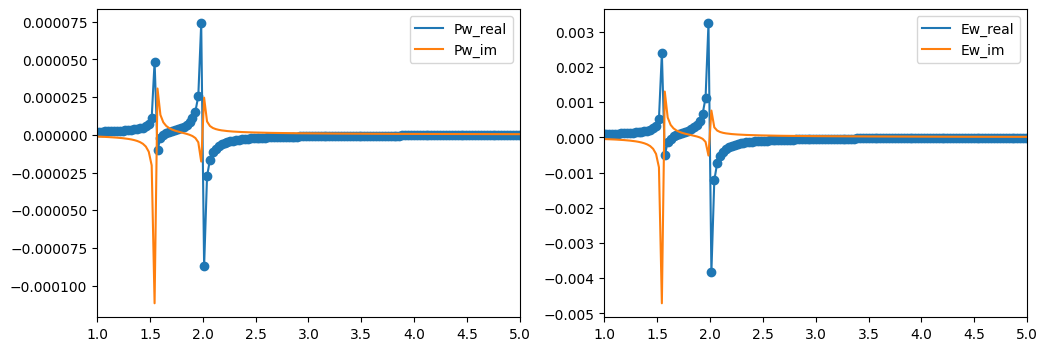

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(12,4))
axes[0].plot(energy,Pw_real,label='Pw_real')
axes[0].scatter(energy,Pw_real)
axes[0].plot(energy,Pw_im,label='Pw_im')
axes[0].set_xlim(1,5)
axes[0].legend()
axes[1].plot(energy,Ew_real,label='Ew_real')
axes[1].scatter(energy,Ew_real)
axes[1].plot(energy,Ew_im,label='Ew_im')
axes[1].set_xlim(1,5)
axes[1].legend()

In [14]:
energy[0:100]

array([0.        , 0.02757112, 0.05514224, 0.08271335, 0.11028447,
       0.13785559, 0.16542671, 0.19299783, 0.22056894, 0.24814006,
       0.27571118, 0.3032823 , 0.33085342, 0.35842453, 0.38599565,
       0.41356677, 0.44113789, 0.46870901, 0.49628012, 0.52385124,
       0.55142236, 0.57899348, 0.6065646 , 0.63413571, 0.66170683,
       0.68927795, 0.71684907, 0.74442019, 0.7719913 , 0.79956242,
       0.82713354, 0.85470466, 0.88227578, 0.90984689, 0.93741801,
       0.96498913, 0.99256025, 1.02013137, 1.04770248, 1.0752736 ,
       1.10284472, 1.13041584, 1.15798695, 1.18555807, 1.21312919,
       1.24070031, 1.26827143, 1.29584254, 1.32341366, 1.35098478,
       1.3785559 , 1.40612702, 1.43369813, 1.46126925, 1.48884037,
       1.51641149, 1.54398261, 1.57155372, 1.59912484, 1.62669596,
       1.65426708, 1.6818382 , 1.70940931, 1.73698043, 1.76455155,
       1.79212267, 1.81969379, 1.8472649 , 1.87483602, 1.90240714,
       1.92997826, 1.95754938, 1.98512049, 2.01269161, 2.04026

We have to understand how to extract the non-linear chi from these functions

In [15]:
from yambopy import *
from yambopy.nl.sum_frequencies import SF_Harmonic_Analysis
from yambopy.units import fs2aut

In [16]:
X_order=3
NLDB=YamboNLDB(folder=run_dir,calc='test2',nl_db='ndb.Nonlinear')
SF_harm_analysis = SF_Harmonic_Analysis(NLDB,X_order=X_order,prn_Peff=True,prn_Xhi=True) #,T_range=[50.0*fs2aut,-1.0]

Field 3 not found

* * * Sum/difference frequency generation: harmonic analysis * * *

Frequency of the second field : 1.55 [eV]
Number of frequencies : 4 
Minimum frequency :  2.0  [eV] 
Maximum frequency :  2.75  [eV] 
Effective max time period for field1  2.0678336321220474 [fs] 
Initial time range :  39.492713285266994 - 149.95000000000002  [fs] 
Pump frequency :  1.55  [eV] 
 Number of coefficents : 49
 Number of sampling points : 98
Loop in frequecies...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 12.58it/s]


Calculate susceptibility 
Reconstruct effective polarizations ...


12it [00:00, 48.03it/s]


Write reconstructed polarizations ...


...

Write sampling ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 312.28it/s]


Print general error in P(t) reconstruction 
Write error ...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 1949.93it/s]


Write susceptibilities ...


Move the output files in a separate folder

In [17]:
harm_analysis_path = 'kx8_nb100_NoTr_E100/test2_harm_analysis'

if os.path.exists(harm_analysis_path):
    shutil.rmtree(harm_analysis_path)

os.makedirs(harm_analysis_path)

for filename in os.listdir('.'):
    if filename.startswith('o-test2.YamboPy-'):
        shutil.move(filename, harm_analysis_path)

Parse the harmonic analysis results to understand what is happening

In [18]:
data = U.Utils.file_parser(os.path.join(harm_analysis_path,'o-test2.YamboPy-pol_reconstructed_F1'))

In [19]:
time_sf = data[0]
Px_sf = data[1]

In [20]:
freq = 'F1'
time = results[0].data['NL_Etot_%s'%freq]['col1']
Px = results[0].data['NL_pol_%s'%freq]['col2']

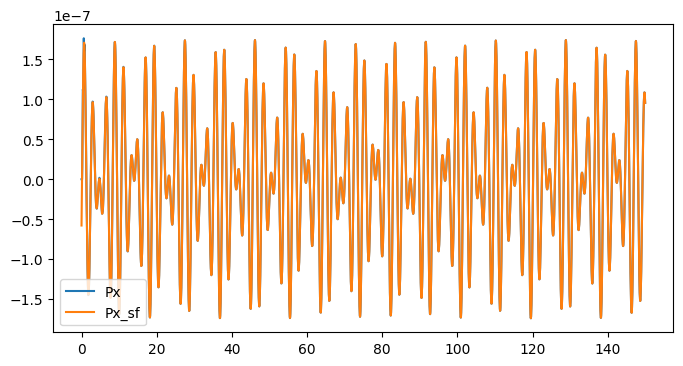

In [21]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(time,Px,label='Px')
ax1.plot(time_sf,Px_sf,label='Px_sf')
ax1.legend()

I want to understand how to extract the chi's directly from here

In [22]:
SF_harm_analysis[0].shape

(7, 7, 4, 3)

In [23]:
chis = SF_harm_analysis[0]
chis.shape

(7, 7, 4, 3)

In [24]:
chis[0,0]

array([[-3.50962385e-16-2.90028188e-16j, -0.00000000e+00+0.00000000e+00j,
        -0.00000000e+00+0.00000000e+00j],
       [-2.71572545e-17+4.90631411e-17j, -0.00000000e+00+0.00000000e+00j,
        -0.00000000e+00+0.00000000e+00j],
       [ 2.66386417e-16+1.52054841e-16j, -0.00000000e+00+0.00000000e+00j,
        -0.00000000e+00+0.00000000e+00j],
       [-6.41250082e-17-1.50791686e-16j, -0.00000000e+00+0.00000000e+00j,
        -0.00000000e+00+0.00000000e+00j]])

In [25]:
# 0,0 means -3,-3 order chi
chis[0,0,:,0] # x component real and imag part for all the frequencies

array([-3.50962385e-16-2.90028188e-16j, -2.71572545e-17+4.90631411e-17j,
        2.66386417e-16+1.52054841e-16j, -6.41250082e-17-1.50791686e-16j])

In [26]:
# 0,1 means -3,-2 order chi
chis[0,1,:,0] # x component real and imag part for all the frequencies

array([-4.69681009e-15-6.79546462e-15j,  1.03471742e-15-6.86905311e-15j,
       -1.21752628e-14+1.36138204e-14j,  1.57797435e-15-2.17425620e-15j])

In [27]:
# 5,5 means 2,2 order chi
chis[5,5,:,0] # x component real and imag part for all the frequencies

array([-4.68150329e-13+1.68136937e-13j, -1.17688875e-13-1.67572867e-13j,
        2.44933280e-13-1.12542166e-13j, -1.35155180e-13-1.52485101e-13j])

\begin{eqnarray}
\chi^{neq,(1)}[E_P](\omega) &=& \chi^{(1)}(\omega;\omega) + \nonumber \\
&+& \left[ \chi^{(2)}(\omega;\omega_P,\omega-\omega_P)\frac{E_{p}(\omega-\omega_P)}{E_p(\omega)} + 
\chi^{(2)}(\omega;-\omega_P,\omega+\omega_P)\frac{E_{p}(\omega+\omega_P)}{E_p(\omega)}
\right]E_{P}(\omega_P)  + \nonumber \\ &+&\left[   
\chi^{(3)}(\omega;\omega_P,\omega_P,\omega-2\omega_P)\frac{E_{p}(\omega-2\omega_P)}{E_p(\omega)} + 
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) + \right. \nonumber \\ &&\left.
\chi^{(3)}(\omega;-\omega_P,-\omega_P,\omega+2\omega_P)\frac{E_{p}(\omega+2\omega_P)}{E_p(\omega)}
\right]E^2_{P}(\omega_P)
\end{eqnarray}

I try to identify the chis relevant for this equation. First we are in the linear response regime for the probe (first field) so only the chis[2,...] (probe at $-\omega$) and
chis[4,...] (probe at $\omega$) are needed

### Linear term $\chi^{(1)}(\omega;\omega)$

This term has zero order in the pump so it corresponds to chis[4,3,...] and chis[2,3,...]. The two terms are related since $P(t)$ is real
which implies that $P^*(-\omega)=P(\omega)$

In [28]:
chis[4,3,:,0]

array([0.02148631+0.00863979j, 0.02113455+0.00969589j,
       0.02074136+0.01074363j, 0.02030683+0.01178217j])

In [29]:
chis[2,3,:,0]

array([-0.02148631+0.00863979j, -0.02113455+0.00969589j,
       -0.02074136+0.01074363j, -0.02030683+0.01178217j])

It seems that there is an extra minus sign that should come from the Fourier representation of the sine field (check)

### Quadratic terms $\chi^{(2)}$

In this case we got

In [32]:
chis[4,2,:,0] # w probe = w of the range, w pump = 1.55

(array([-1.79714511e-10+6.57585229e-11j, -2.45409279e-10-2.23826603e-10j,
        -5.83187282e-11+1.35957999e-10j,  2.80766538e-10+1.99780214e-10j]),
 array([-2.10695639e-10-1.94163383e-10j, -8.96014359e-11-8.73350811e-11j,
         1.75955949e-11+9.12815586e-11j,  4.47040334e-11+2.00199054e-10j]))

In [34]:
chis[4,4,:,0] # w probe = w of the range, w pump = -1.55

array([-2.10695639e-10-1.94163383e-10j, -8.96014359e-11-8.73350811e-11j,
        1.75955949e-11+9.12815586e-11j,  4.47040334e-11+2.00199054e-10j])

The values of the two chis are different but they are giving contribution to different omega value so this is expected.
The actual contribution is at omega value
$$
\omega_{range}+w_{pump} \,\, , \qquad \omega_{range}-w_{pump} 
$$

The are also terms for $\omega_{probe} = - \omega_{range}$ that are connected to the previous two and give contribution
for overhall negative value of $\omega$ so I believe that these kind of contribution should not be included since we are
intereseted in building the response for positive omegas

In [37]:
chis[2,2,:,0] # w probe = -w of the range, w pump = 1.55

array([-2.10695639e-10+1.94163383e-10j, -8.96014360e-11+8.73350810e-11j,
        1.75955950e-11-9.12815581e-11j,  4.47040331e-11-2.00199054e-10j])

In [38]:
chis[2,4,:,0] # w probe = -w of the range, w pump = -1.55

array([-1.79714511e-10-6.57585228e-11j, -2.45409279e-10+2.23826603e-10j,
       -5.83187285e-11-1.35957999e-10j,  2.80766539e-10-1.99780214e-10j])

### Cubic terms $\chi^{(3)}$

In [39]:
chis[4,1,:,0] # w probe = w of the range, w pump = -2*1.55

array([ 6.69105752e-12+4.08280525e-12j, -6.80452638e-12+2.67846406e-12j,
        9.57458743e-12-6.45471130e-12j,  1.22429462e-12+9.95356195e-12j])

In [40]:
chis[4,3,:,0] # w probe = w of the range, w pump = 0

array([0.02148631+0.00863979j, 0.02113455+0.00969589j,
       0.02074136+0.01074363j, 0.02030683+0.01178217j])

In [41]:
chis[4,5,:,0] # w probe = w of the range, w pump = 2*1.55

array([-4.55654073e-13+1.67749682e-11j, -7.14491335e-12-3.23657100e-12j,
        1.01597463e-11+1.27251413e-11j,  2.61059737e-12+2.45979122e-12j])

We observe that the term $\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega)$ is the leading contribution so the non-linear response should be
expressed in terms of this term only.

## Calculation of the non-linear $\chi$

In order to compute these quantities we perform a RT simulation using yambo_nl and then we extract the chi's using a postprocessing. Both an analysis based on the yambopy package and an original analysis developed here will be performed 

### RT simulation with yambo_nl in the IP approximation

As a first step we peform the RT simulation in the IP approximation.

WE choose the parameters from the folder

/work/sangalli/simulations/LiF/yambo/e80_kx6_pbe_sr/kx8_nb100/NoTr_E100/sh6.0+str0.05_probes/tdberry

and in particular from td-ip-ber_3.0as_inv_3-12b_delta1.0fs_deph0.1fs_p_NL, reducing the bands to 3-6

SOFTSIN:  E(t)= (c*t^2 + b*t^3 + a*t^4 )* sin(t)  and 0 for t<=0

In [3]:
# RunRules for ismhpc
# The product of ntasks_per_node*cpus_per_task is equal to 32. 
# Many mpi are needed for better performances
nodes = 1
ntasks_per_node = 32 #16
cpus_per_task = 1 #2
omp_num_threads = 1 #2
module = '/home/dalessandro/module_script/yambo_module'

ntasks = nodes*ntasks_per_node

rr = C.RunRules(scheduler='slurm',partition='all12h', #'all12h',
                memory='125000',
                nodes=nodes,ntasks_per_node=ntasks_per_node,
                cpus_per_task=cpus_per_task,
                omp_num_threads=omp_num_threads,pre_processing=module)
code = C.YamboCalculator(rr,executable='yambo_nl',activate_BeeOND=True)
#code.global_options()

Initialize a Yambo calculator with scheduler slurm


In [4]:
run_dir = 'kx8_nb100_NoTr_E100/'

In [13]:
NLBands = [3,6]
GfnQP_E = [6.,1.05,1.05]
NLEnRange = [10.0,15.0] # energy range of the probe
NLEnSteps = 25 # number of steps for the loop on frequencies

Field1_Freq, Field2_Freq = -0.1, 1.55 # eV Energy of the pump pulse
Field1_Int, Field2_Int = 1000, 1000
Field1_Dir, Field2_Dir = [1.,0.,0.], [1.,0.,0.]
Field1_kind, Field2_kind = ' SOFTSIN', ' SOFTSIN'
Field1_Tstart, Field2_Tstart = 0.1, 0.1 # fs
NLDamping = 0.2 # eV
NLtime, NLstep = 150, 0.05  # fs
IOtime = [1.,5.,0.005] #fs

inp = I.YamboInput(args='yambo_nl -u n',folder=run_dir)
inp.set_array_variables(NLBands=NLBands,GfnQP_E=GfnQP_E,NLEnSteps=NLEnSteps)
inp.set_array_variables(units='eV',NLEnRange=NLEnRange,Field1_Freq=Field1_Freq,Field2_Freq=Field2_Freq,NLDamping=NLDamping)
inp.set_array_variables(units='kWLm2',Field1_Int=Field1_Int,Field2_Int=Field2_Int)
inp.set_array_variables(Field1_Dir=Field1_Dir,Field2_Dir=Field2_Dir)
inp.set_array_variables(units='fs',Field1_Tstart=Field1_Tstart,Field2_Tstart=Field2_Tstart,NLtime=NLtime,NLstep=NLstep)
inp.set_scalar_variables(Field1_kind=Field1_kind,Field2_kind=Field2_kind)
inp.set_array_variables(units='fs',IOtime=IOtime)
inp.set_scalar_variables(NL_ROLEs="w.k",NL_CPU='4.8')
#inp

In [14]:
study = D.Dataset(num_tasks=1,run_dir=run_dir,verbose=True)
study.set_postprocessing_function(PP.yambo_parse_data)
idd = 'pump_1.55-probe_10-15-bands_3-6-damp_0.2-sofsin'
study.append_run(id=idd,input=inp,runner=code,jobname=[idd]) #,reformat=False

Initialize a Dataset with 1 parallel tasks


In [15]:
# study.runs[0]

In [16]:
results = study.run()

Run the selection [0] with the parallel task_groups [[0]] 

Run the task [0] 
Skip the run of pump_1.55-probe_10-15-bands_3-6-damp_0.2-sofsin


--------------------------------------------------------------------------

  Local host:   frontend
  Local device: mlx5_0
--------------------------------------------------------------------------


Task [0] ended 
 


We extract the non-linear chi using the YamboPy tool

In [17]:
from yambopy import *
from yambopy.nl.sum_frequencies import SF_Harmonic_Analysis
from yambopy.units import fs2aut

In [19]:
X_order=3
NLDB=YamboNLDB(folder=run_dir,calc='pump_1.55-probe_10-15-bands_3-6-damp_0.2-sofsin',nl_db='ndb.Nonlinear')
SF_harm_analysis = SF_Harmonic_Analysis(NLDB,X_order=X_order,prn_Peff=False,prn_Xhi=False) #,T_range=[50.0*fs2aut,-1.0]

Field 3 not found

* * * Sum/difference frequency generation: harmonic analysis * * *

Frequency of the second field : 1.55 [eV]
Number of frequencies : 25 
Minimum frequency :  10.0  [eV] 
Maximum frequency :  14.8  [eV] 
Effective max time period for field1  0.41356672642440945 [fs] 
Initial time range :  39.492713285266994 - 149.95000000000002  [fs] 
Pump frequency :  1.55  [eV] 
 Number of coefficents : 49
 Number of sampling points : 98
Loop in frequecies...


100%|██████████| 25/25 [00:01<00:00, 19.44it/s]


Calculate susceptibility 
Reconstruct effective polarizations ...


75it [00:01, 55.60it/s]


Write reconstructed polarizations ...


...

Write sampling ...


100%|██████████| 25/25 [00:00<00:00, 415.35it/s]


Print general error in P(t) reconstruction 
Write error ...


100%|██████████| 25/25 [00:00<00:00, 3408.67it/s]

Write susceptibilities ...


I want to understand how to extract the chi's directly from here

In [23]:
chis = SF_harm_analysis[0]
chis.shape

(7, 7, 25, 3)

\begin{eqnarray}
\chi^{neq,(1)}[E_P](\omega) &=& \chi^{(1)}(\omega;\omega) + \nonumber \\
&+& \left[ \chi^{(2)}(\omega;\omega_P,\omega-\omega_P)\frac{E_{p}(\omega-\omega_P)}{E_p(\omega)} + 
\chi^{(2)}(\omega;-\omega_P,\omega+\omega_P)\frac{E_{p}(\omega+\omega_P)}{E_p(\omega)}
\right]E_{P}(\omega_P)  + \nonumber \\ &+&\left[   
\chi^{(3)}(\omega;\omega_P,\omega_P,\omega-2\omega_P)\frac{E_{p}(\omega-2\omega_P)}{E_p(\omega)} + 
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) + \right. \nonumber \\ &&\left.
\chi^{(3)}(\omega;-\omega_P,-\omega_P,\omega+2\omega_P)\frac{E_{p}(\omega+2\omega_P)}{E_p(\omega)}
\right]E^2_{P}(\omega_P)
\end{eqnarray}

I try to identify the chis relevant for this equation. First we are in the linear response regime for the probe (first field) so only the chis[2,...] (probe at $-\omega$) and
chis[4,...] (probe at $\omega$) are needed

### Linear term $\chi^{(1)}(\omega;\omega)$

This term has zero order in the pump so it corresponds to chis[4,3,...] and chis[2,3,...]. The two terms are related since $P(t)$ is real
which implies that $P^*(-\omega)=P(\omega)$

In [27]:
chi1 = chis[4,3,:,0]
omegas = np.linspace(10.,14.8,num=25)

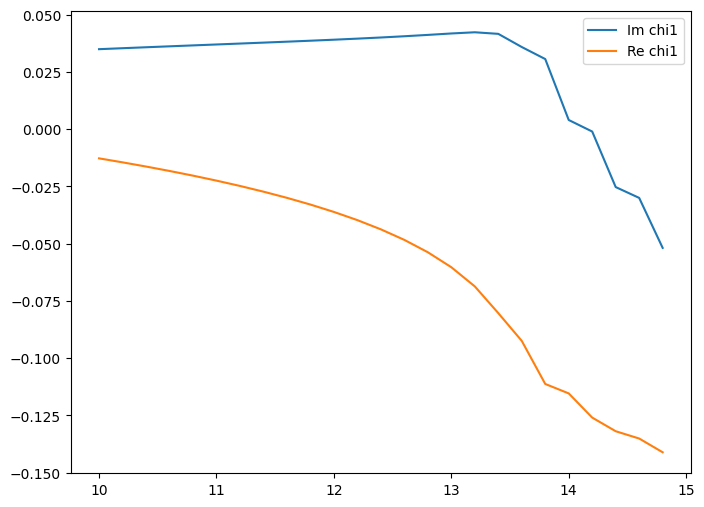

In [34]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(omegas,np.imag(chi1),label='Im chi1')
ax1.plot(omegas,np.real(chi1),label='Re chi1')
ax1.legend()

### Quadratic terms $\chi^{(2)}$

In this case we got

In [35]:
chis[4,2,:,0] # w probe = w of the range, w pump = 1.55

array([ 2.08680240e-10+9.66897326e-10j, -1.37522172e-10-3.36241122e-10j,
       -1.87276133e-09-2.93886108e-10j, -3.58330038e-10+2.67121433e-11j,
        1.09843176e-10+2.93176462e-09j, -2.51060900e-09+1.19924239e-09j,
       -3.36947254e-09-1.63282908e-09j, -2.34708808e-09-1.88474521e-09j,
       -4.50608690e-10-8.08957835e-10j, -7.53739796e-10-2.18096449e-10j,
       -2.27272498e-09+6.93849204e-10j, -1.13491875e-09-1.76135077e-09j,
       -1.36971842e-09-3.10414111e-09j,  1.03236432e-09-4.19704902e-09j,
        2.85264900e-11-4.53107466e-09j, -2.67363263e-10-6.19971488e-09j,
       -9.15572470e-10-9.96549921e-09j,  4.76657123e-09-1.66309979e-08j,
        4.51351988e-08+2.50777149e-09j,  2.26127301e-08+3.01450125e-08j,
        9.62182695e-09+5.86845100e-08j, -6.06814713e-08+5.64186793e-08j,
       -4.88118595e-08-9.81549790e-09j, -1.29825856e-08-7.59614787e-08j,
        1.40166570e-08-8.04531477e-09j])

In [36]:
chis[4,4,:,0] # w probe = w of the range, w pump = -1.55

array([ 1.05432746e-11+1.71345702e-10j, -1.48407928e-09-1.33698494e-09j,
       -4.91864907e-10-1.12603381e-09j, -1.27670144e-09+8.14666019e-10j,
       -2.02267645e-09+1.54133995e-09j, -2.82720646e-09+4.29908102e-10j,
       -1.46397737e-09+4.62344972e-10j, -8.82773660e-10+2.95476652e-09j,
        1.07634735e-09+2.46879163e-09j,  7.86750590e-11+3.86021900e-09j,
       -1.74686816e-09+6.85061569e-09j, -7.04086667e-09+9.17052661e-09j,
       -2.23304979e-08+2.14755942e-09j, -8.50029747e-09-4.45632352e-09j,
       -1.47884953e-08-1.63336629e-09j, -1.65911068e-08-8.24646543e-09j,
       -1.94243976e-08-2.49181528e-08j, -1.78122665e-08-5.67476627e-08j,
        6.73511920e-08-2.30143392e-08j,  5.24544149e-08+4.53325585e-09j,
        9.19231028e-09+8.46482827e-08j, -1.17019387e-07-1.30990851e-08j,
        3.16501838e-08-2.58934163e-08j,  4.31687982e-08-5.68434809e-08j,
        2.50255801e-08+1.99603217e-08j])

The values of the two chis are different but they are giving contribution to different omega value so this is expected.
The actual contribution is at omega value
$$
\omega_{range}+w_{pump} \,\, , \qquad \omega_{range}-w_{pump} 
$$

The are also terms for $\omega_{probe} = - \omega_{range}$ that are connected to the previous two and give contribution
for overhall negative value of $\omega$ so I believe that these kind of contribution should not be included since we are
intereseted in building the response for positive omegas

In [37]:
chis[2,2,:,0] # w probe = -w of the range, w pump = 1.55

array([ 1.05432752e-11-1.71345702e-10j, -1.48407928e-09+1.33698494e-09j,
       -4.91864907e-10+1.12603381e-09j, -1.27670144e-09-8.14666019e-10j,
       -2.02267645e-09-1.54133995e-09j, -2.82720646e-09-4.29908103e-10j,
       -1.46397737e-09-4.62344973e-10j, -8.82773659e-10-2.95476652e-09j,
        1.07634735e-09-2.46879163e-09j,  7.86750597e-11-3.86021900e-09j,
       -1.74686816e-09-6.85061569e-09j, -7.04086667e-09-9.17052661e-09j,
       -2.23304979e-08-2.14755942e-09j, -8.50029747e-09+4.45632352e-09j,
       -1.47884953e-08+1.63336629e-09j, -1.65911068e-08+8.24646543e-09j,
       -1.94243976e-08+2.49181528e-08j, -1.78122665e-08+5.67476627e-08j,
        6.73511920e-08+2.30143392e-08j,  5.24544149e-08-4.53325585e-09j,
        9.19231028e-09-8.46482827e-08j, -1.17019387e-07+1.30990851e-08j,
        3.16501838e-08+2.58934163e-08j,  4.31687982e-08+5.68434809e-08j,
        2.50255801e-08-1.99603217e-08j])

In [38]:
chis[2,4,:,0] # w probe = -w of the range, w pump = -1.55

array([ 2.08680239e-10-9.66897326e-10j, -1.37522172e-10+3.36241122e-10j,
       -1.87276133e-09+2.93886107e-10j, -3.58330038e-10-2.67121422e-11j,
        1.09843176e-10-2.93176462e-09j, -2.51060900e-09-1.19924239e-09j,
       -3.36947254e-09+1.63282908e-09j, -2.34708808e-09+1.88474521e-09j,
       -4.50608690e-10+8.08957835e-10j, -7.53739797e-10+2.18096449e-10j,
       -2.27272498e-09-6.93849203e-10j, -1.13491875e-09+1.76135077e-09j,
       -1.36971842e-09+3.10414111e-09j,  1.03236432e-09+4.19704903e-09j,
        2.85264906e-11+4.53107466e-09j, -2.67363263e-10+6.19971488e-09j,
       -9.15572468e-10+9.96549921e-09j,  4.76657123e-09+1.66309979e-08j,
        4.51351988e-08-2.50777149e-09j,  2.26127301e-08-3.01450125e-08j,
        9.62182695e-09-5.86845100e-08j, -6.06814713e-08-5.64186793e-08j,
       -4.88118595e-08+9.81549790e-09j, -1.29825856e-08+7.59614787e-08j,
        1.40166570e-08+8.04531477e-09j])

### Cubic terms $\chi^{(3)}$

In [39]:
chis[4,1,:,0] # w probe = w of the range, w pump = -2*1.55

array([ 4.12420411e-12+5.04499262e-12j, -9.72984100e-12+1.87404264e-11j,
       -4.61973228e-11-5.33242828e-12j,  6.04068691e-11-1.26815346e-11j,
        6.98102712e-11+1.23194912e-11j,  2.33651872e-11+8.52280789e-11j,
        6.62942470e-11-7.34335166e-12j,  8.44650244e-11+5.68874319e-11j,
        1.47399642e-11+3.46423648e-11j, -1.26901243e-11+8.52846042e-12j,
       -3.47488619e-11+2.68742266e-11j, -6.02658667e-11+6.82759213e-11j,
        1.77553226e-10-1.47715762e-10j, -1.01612494e-10-6.32032316e-11j,
        1.06051121e-10-1.46235212e-10j,  5.97814354e-12-2.82115058e-11j,
        5.17569334e-11-1.12911146e-10j,  2.74768034e-11-1.74736562e-10j,
       -6.84420266e-11-4.43305027e-11j, -3.10250238e-11-3.45871079e-11j,
       -2.23475574e-10+1.47451813e-10j,  1.60442194e-10+2.91430154e-11j,
        3.52792710e-11+2.78563698e-11j, -3.33052609e-11+1.32634233e-10j,
        2.25728926e-10-3.10506765e-10j])

In [40]:
chis[4,3,:,0] # w probe = w of the range, w pump = 0

array([-0.01271942+0.03497507j, -0.01446057+0.03539764j,
       -0.01629223+0.03581274j, -0.01822484+0.0362218j ,
       -0.02027123+0.03662659j, -0.02244693+0.03702898j,
       -0.02477096+0.03743141j, -0.02726664+0.03783725j,
       -0.02996355+0.03824983j, -0.03289971+0.03867412j,
       -0.03612437+0.03911561j, -0.03970393+0.03958138j,
       -0.04373076+0.04008001j, -0.0483391 +0.04062137j,
       -0.05373672+0.04121129j, -0.06027693+0.04183618j,
       -0.06865104+0.04235838j, -0.08032661+0.04166845j,
       -0.09245896+0.0359176j , -0.11127891+0.03066224j,
       -0.11540647+0.00403799j, -0.12597351-0.00100951j,
       -0.1319297 -0.02526497j, -0.13511866-0.02999844j,
       -0.14112304-0.05183057j])

In [41]:
chis[4,5,:,0] # w probe = w of the range, w pump = 2*1.55

array([ 5.08904362e-11+1.36655984e-11j,  3.27557152e-12+1.49138468e-11j,
       -5.11415362e-11+4.39539464e-12j, -2.34817002e-11-1.28011151e-11j,
        4.62860815e-11-7.26161111e-12j,  1.11869433e-10+1.65649625e-11j,
       -3.96499124e-11+6.96292977e-11j,  2.43512162e-11-2.36150952e-12j,
       -7.99922856e-11-3.64666370e-11j, -1.49007242e-12-2.70280576e-11j,
        3.27366047e-11-5.11224080e-11j,  5.44375699e-12-5.24427290e-11j,
        7.12857659e-11-1.84036789e-10j,  3.72856572e-11-4.88647741e-11j,
        6.57323855e-11-2.05727955e-12j,  1.22038637e-10-1.77958696e-11j,
        1.70932879e-10+1.42130075e-10j,  1.08317584e-11+7.13104301e-11j,
       -7.61465152e-11+4.92007479e-11j, -1.87327798e-10-3.69610920e-11j,
       -4.79958930e-12-5.63354509e-12j,  2.70745033e-10+7.19098611e-11j,
       -4.70742421e-11+1.61994488e-10j, -1.96144622e-10+1.89589273e-10j,
        3.37497315e-10+3.19797408e-12j])

We observe that the term $\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega)$ is the leading contribution so the non-linear response should be
expressed in terms of this term only.

In [42]:
chi3 = chis[4,3,:,0]

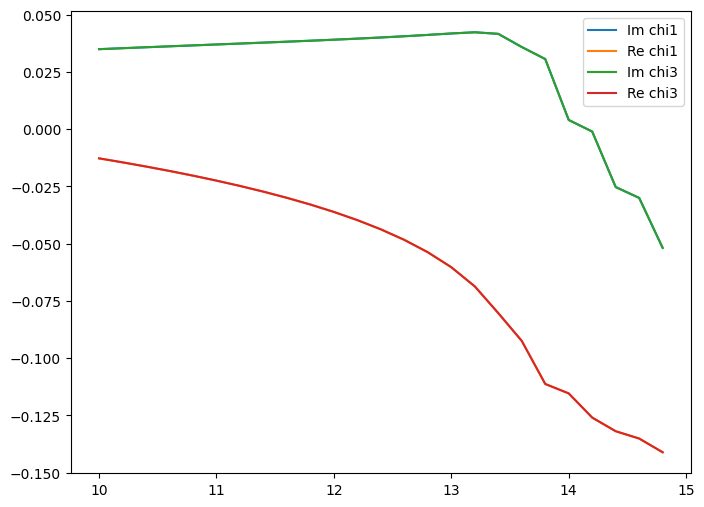

In [46]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(omegas,np.imag(chi1),label='Im chi1')
ax1.plot(omegas,np.real(chi1),label='Re chi1')
ax1.plot(omegas,np.imag(chi3),label='Im chi3')
ax1.plot(omegas,np.real(chi3),label='Re chi3')
ax1.legend()

In [ ]:
##########################################################################

% NLBands
 18   3 |  12 |                   # [NL] Bands
 19 %
 20 
 21 % GfnQP_E
 22  6.00000 | 1.05000 | 1.0500 |        # (1.7 less of what needed)  [EXTQP RT] E parameters  (c/v) eV|adim|adim
 23 %
 24 
 25 NLverbosity= "high"              # [NL] Verbosity level (low | high)
 26 NLstep= 3.00000           as    # [NL] Time step length
 27 NLtime= 40.0000         fs      # [NL] Simulation Time
 28 NLintegrator= "CRANKNIC"           # [NL] Integrator ("EULEREXP/RK2/RK4/RK2EXP/HEUN/INVINT/CRANKNIC")
 29 NLCorrelation= "IPA"             # [NL] Correlation ("IPA/HARTREE/TDDFT/LRC/LRW/JGM/SEX") CVONLY forced
 30 NLDamping= 0.1000        eV      # [NL] Damping (or dephasing)
 31 
 32 % IOtime
 33   1.00     | 5.00    | 0.005     |  fs    # [RT] Time between to consecutive I/O (OBSERVABLEs - GF - OUTPUT)
 34 %

 NL_CPU= "1.8"              # [PARALLEL] CPUs for each role
 NL_ROLEs= "w.k"           # [PARALLEL] CPUs roles (k,b,q,qp)
 DIP_CPU= "8.1.1.1"              # [PARALLEL] CPUs for each role
 DIP_ROLEs= "k.c.v"           # [PARALLEL] CPUs roles (k,b,q,qp)